# Realized Volatility - Dynamic σ for Spread Sizing

**Purpose:** Replace the fixed σ in the A-S model with a dynamic, symbol-specific,  
time-varying estimate of realized volatility.

**Current state:** σ is hardcoded or estimated once — same value all day, every day.  
**Goal:** σ that adapts in real-time to market conditions.

## Why This Matters
The A-S optimal spread formula is:
$$\delta^* = \gamma \sigma^2 T + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa}\right)$$

σ² appears directly in the spread. If σ doubles, optimal spread quadruples.  
On a high-volatility day like May 15, using a low fixed σ means:
- Spread too tight → getting adversely selected repeatedly
- Inventory builds up on wrong side → losses compound

On a low-volatility day, fixed σ means:
- Spread too wide → fewer fills → missed PnL

## What We're Measuring
1. **Intraday vol profile** — how does σ vary through the day?
2. **Day-to-day vol variation** — how different was May 13 vs 14 vs 15?
3. **Vol windows** — which realized_vol_Xs column is most predictive of next-period vol?
4. **Vol regimes** — low/medium/high vol periods and what spread each requires
5. **Practical σ estimate** — what formula to use in mm_strategy.py

## Available Vol Columns
```
realized_vol_10s   — 10-second realized vol
realized_vol_30s   — 30-second realized vol  
realized_vol_60s   — 60-second realized vol  ← likely best for MM
realized_vol_300s  — 5-minute realized vol
```

---

## 0. Imports & Config

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gcsfs
from matplotlib.patches import Patch
from scipy.stats import pearsonr
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

GCP_PROJECT  = 'hedge-fund-494103'
GCS_BUCKET   = 'hedge-fund-494103-marketdata'
GCS_PREFIX   = 'processed/features'
FINDINGS_DIR = '../findings'

SYMBOLS = [
    'CHOLAFIN26MAYFUT',
    'ADANIPORTS26MAYFUT',
    'DRREDDY26MAYFUT',
    'ADANIENT26MAYFUT',
    'HAVELLS26MAYFUT',
    'JSWSTEEL26MAYFUT',
    'RELIANCE26MAYFUT',
]

DATES = ['2026-05-13', '2026-05-14', '2026-05-15']

VOL_COLS = ['realized_vol_10s', 'realized_vol_30s', 'realized_vol_60s', 'realized_vol_300s']

# Current hardcoded params
GAMMA     = 0.001
KAPPA     = 1.5

os.makedirs(FINDINGS_DIR, exist_ok=True)
print('Config loaded.')

c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Config loaded.


## 1. Load Data

In [2]:
fs = gcsfs.GCSFileSystem(project=GCP_PROJECT)

def load_symbol(symbol: str, dates: list) -> pd.DataFrame:
    frames = []
    for date in dates:
        path = f"{GCS_BUCKET}/{GCS_PREFIX}/{symbol}/{date}.parquet"
        if not fs.exists(path):
            print(f'  [MISS] {symbol} / {date}')
            continue
        df = pd.read_parquet(f"gs://{path}")
        df['date'] = date
        frames.append(df)
        print(f'  [OK]   {symbol} / {date} — {len(df):,} bars')
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).sort_values('ts_sec').reset_index(drop=True)
    out['ist_tod_sec'] = (out['ts_sec'] + 19800) % 86400
    out['ist_hhmm']    = out['ist_tod_sec'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    return out


symbol_data = {}
for sym in SYMBOLS:
    print(f'Loading {sym}...')
    df = load_symbol(sym, DATES)
    if not df.empty:
        symbol_data[sym] = df

print(f'\nLoaded {len(symbol_data)}/{len(SYMBOLS)} symbols')

Loading CHOLAFIN26MAYFUT...
  [OK]   CHOLAFIN26MAYFUT / 2026-05-13 — 18,244 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-14 — 17,959 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-15 — 19,156 bars
Loading ADANIPORTS26MAYFUT...
  [OK]   ADANIPORTS26MAYFUT / 2026-05-13 — 19,859 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-14 — 19,188 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-15 — 19,876 bars
Loading DRREDDY26MAYFUT...
  [OK]   DRREDDY26MAYFUT / 2026-05-13 — 20,205 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-14 — 11,551 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-15 — 11,579 bars
Loading ADANIENT26MAYFUT...
  [OK]   ADANIENT26MAYFUT / 2026-05-13 — 17,422 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-14 — 20,602 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-15 — 20,682 bars
Loading HAVELLS26MAYFUT...
  [OK]   HAVELLS26MAYFUT / 2026-05-13 — 18,068 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-14 — 17,384 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-15 — 18,390 bars
Loading JSWSTEEL26MAYFUT...
  [OK]   JSWSTEEL26MAYFUT / 2026-05-1

## 2. Vol Summary Statistics

First look — how volatile are these symbols and how much does vol vary?

In [3]:
vol_summary = {}

print(f"{'Symbol':30s} {'Mean 60s vol':>14} {'Std':>8} {'Min':>8} {'Max':>8} {'CV':>8}")
print('-' * 82)

for sym, df in symbol_data.items():
    # Market hours only: 09:15-15:30 IST
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')]
    v   = mkt['realized_vol_60s'].dropna()
    v   = v[v > 0]

    mean_v = float(v.mean())
    std_v  = float(v.std())
    cv     = std_v / mean_v if mean_v > 0 else 0  # coefficient of variation

    vol_summary[sym] = {
        'mean_vol_60s':   round(mean_v, 6),
        'std_vol_60s':    round(std_v, 6),
        'min_vol_60s':    round(float(v.min()), 6),
        'max_vol_60s':    round(float(v.max()), 6),
        'p25_vol_60s':    round(float(v.quantile(0.25)), 6),
        'p75_vol_60s':    round(float(v.quantile(0.75)), 6),
        'cv':             round(cv, 3),
        'n_bars_mkt':     len(mkt),
    }

    print(f"{sym:30s} {mean_v:>14.6f} {std_v:>8.6f} "
          f"{v.min():>8.6f} {v.max():>8.6f} {cv:>8.3f}")

print()
print('CV = coefficient of variation (std/mean). Higher = more variable vol = more important to use dynamic σ')

Symbol                           Mean 60s vol      Std      Min      Max       CV
----------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                     0.665633 0.591905 0.012910 8.075089    0.889
ADANIPORTS26MAYFUT                   0.791026 0.778859 0.012910 17.389900    0.985
DRREDDY26MAYFUT                      0.735294 0.821166 0.012910 15.263777    1.117
ADANIENT26MAYFUT                     1.602156 1.657496 0.012910 38.699898    1.035
HAVELLS26MAYFUT                      0.480193 0.361421 0.012910 3.608205    0.753
JSWSTEEL26MAYFUT                     0.646333 0.516879 0.012910 5.542137    0.800
RELIANCE26MAYFUT                     0.399338 0.291104 0.012910 4.464181    0.729

CV = coefficient of variation (std/mean). Higher = more variable vol = more important to use dynamic σ


## 3. Intraday Vol Profile

The U-shape: vol is highest at open and close, lowest mid-day.  
This tells us exactly when to widen spreads (open/close) and when to tighten (mid-day).

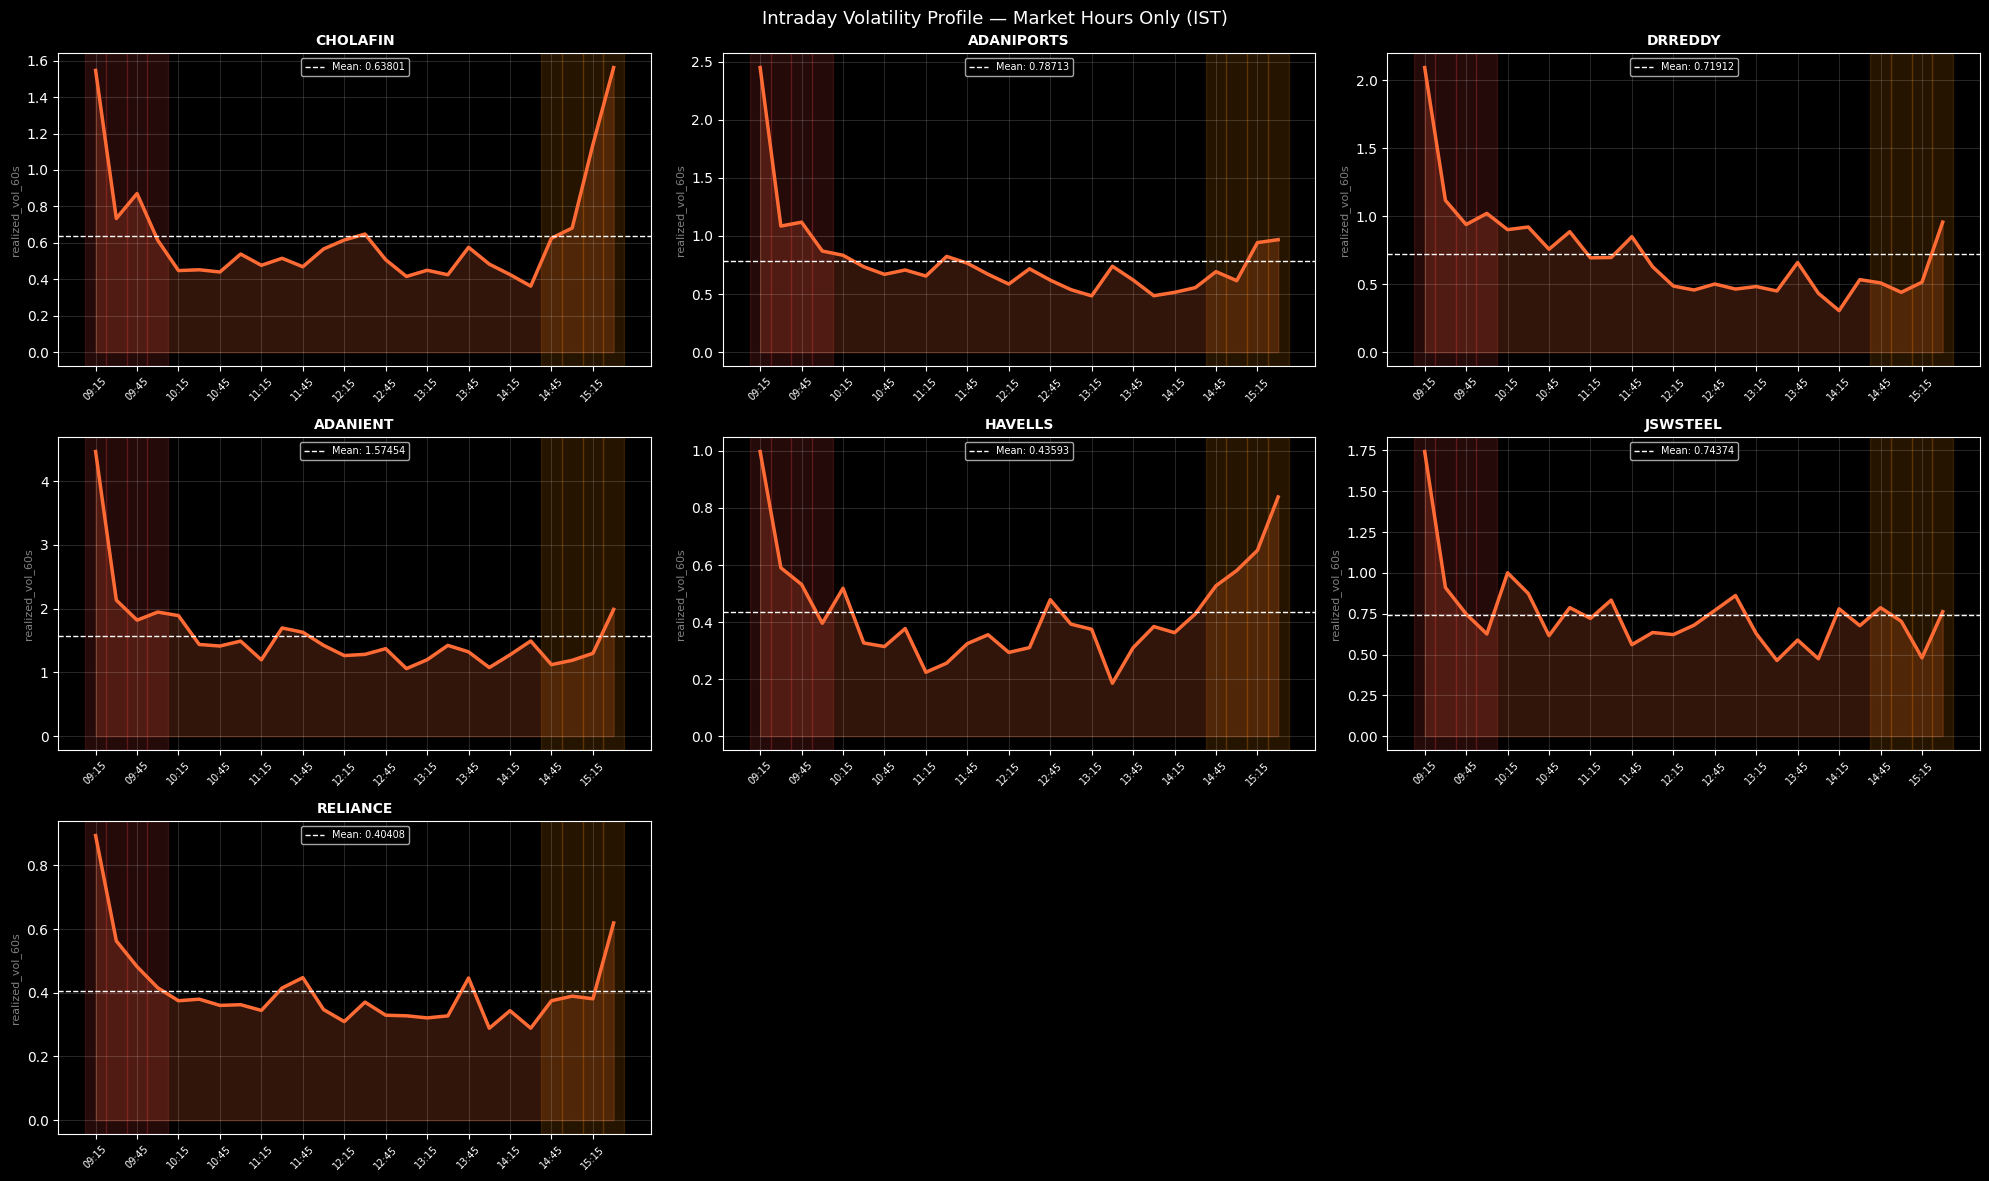

Saved: findings/vol_intraday_profile.png


In [4]:
def vol_by_time(df: pd.DataFrame, vol_col: str = 'realized_vol_60s',
                bucket_min: int = 15) -> pd.DataFrame:
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()
    bucket_sec    = bucket_min * 60
    mkt['bucket'] = (mkt['ist_tod_sec'] // bucket_sec) * bucket_sec
    mkt['hhmm']   = mkt['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    grouped = mkt.groupby(['date', 'hhmm'])[vol_col].mean().reset_index()
    return grouped.groupby('hhmm')[vol_col].mean().reset_index().sort_values('hhmm')


n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

tod_vol_profiles = {}
for i, (sym, df) in enumerate(symbol_data.items()):
    tod = vol_by_time(df)
    tod_vol_profiles[sym] = tod

    ax   = axes[i]
    x    = range(len(tod))
    ax.plot(x, tod['realized_vol_60s'], color='#ff6b35', lw=2.5)
    ax.fill_between(x, tod['realized_vol_60s'], alpha=0.2, color='#ff6b35')

    # Mark open/close windows
    open_idx  = tod[tod['hhmm'] <= '10:00'].index
    close_idx = tod[tod['hhmm'] >= '14:45'].index
    for idx in open_idx:
        if idx < len(x):
            ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.15, color='#ff4444')
    for idx in close_idx:
        if idx < len(x):
            ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.15, color='#ff8c00')

    # Mean vol line
    mean_v = tod['realized_vol_60s'].mean()
    ax.axhline(mean_v, color='white', lw=1, ls='--',
               label=f'Mean: {mean_v:.5f}')

    ax.set_xticks(range(0, len(tod), 2))
    ax.set_xticklabels(tod['hhmm'].iloc[::2], rotation=45, fontsize=7)
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('realized_vol_60s', color='gray', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Intraday Volatility Profile — Market Hours Only (IST)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/vol_intraday_profile.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/vol_intraday_profile.png')

## 4. Day-to-Day Vol Variation

How different was each day? This explains why May 15 was bad —  
if vol was much higher, fixed σ gave too-tight spreads → adverse selection.

In [5]:
day_vol = {}

print(f"{'Symbol':30s} {'May-13':>12} {'May-14':>12} {'May-15':>12} {'Ratio 15/13':>13}")
print('-' * 82)

for sym, df in symbol_data.items():
    mkt    = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')]
    by_day = mkt.groupby('date')['realized_vol_60s'].mean()

    v13 = float(by_day.get('2026-05-13', np.nan))
    v14 = float(by_day.get('2026-05-14', np.nan))
    v15 = float(by_day.get('2026-05-15', np.nan))
    ratio = v15 / v13 if v13 > 0 else np.nan

    day_vol[sym] = {
        '2026-05-13': round(v13, 6),
        '2026-05-14': round(v14, 6),
        '2026-05-15': round(v15, 6),
        'ratio_15_vs_13': round(ratio, 3),
    }

    flag = f' ← {ratio:.1f}x higher' if ratio > 1.5 else ''
    print(f"{sym:30s} {v13:>12.6f} {v14:>12.6f} {v15:>12.6f} {ratio:>13.3f}{flag}")

print()
print('Ratio > 1.5 = May 15 was significantly more volatile → spread should have been wider')

Symbol                               May-13       May-14       May-15   Ratio 15/13
----------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                   0.596979     0.657731     0.469363         0.786
ADANIPORTS26MAYFUT                 0.732946     0.743171     0.854577         1.166
DRREDDY26MAYFUT                    0.825862     0.723348     0.566910         0.686
ADANIENT26MAYFUT                   1.170929     1.651367     1.896475         1.620 ← 1.6x higher
HAVELLS26MAYFUT                    0.449324     0.375530     0.380883         0.848
JSWSTEEL26MAYFUT                   0.880920     0.689990     0.546693         0.621
RELIANCE26MAYFUT                   0.419631     0.401339     0.373548         0.890

Ratio > 1.5 = May 15 was significantly more volatile → spread should have been wider


## 5. Visualize Day-to-Day Vol

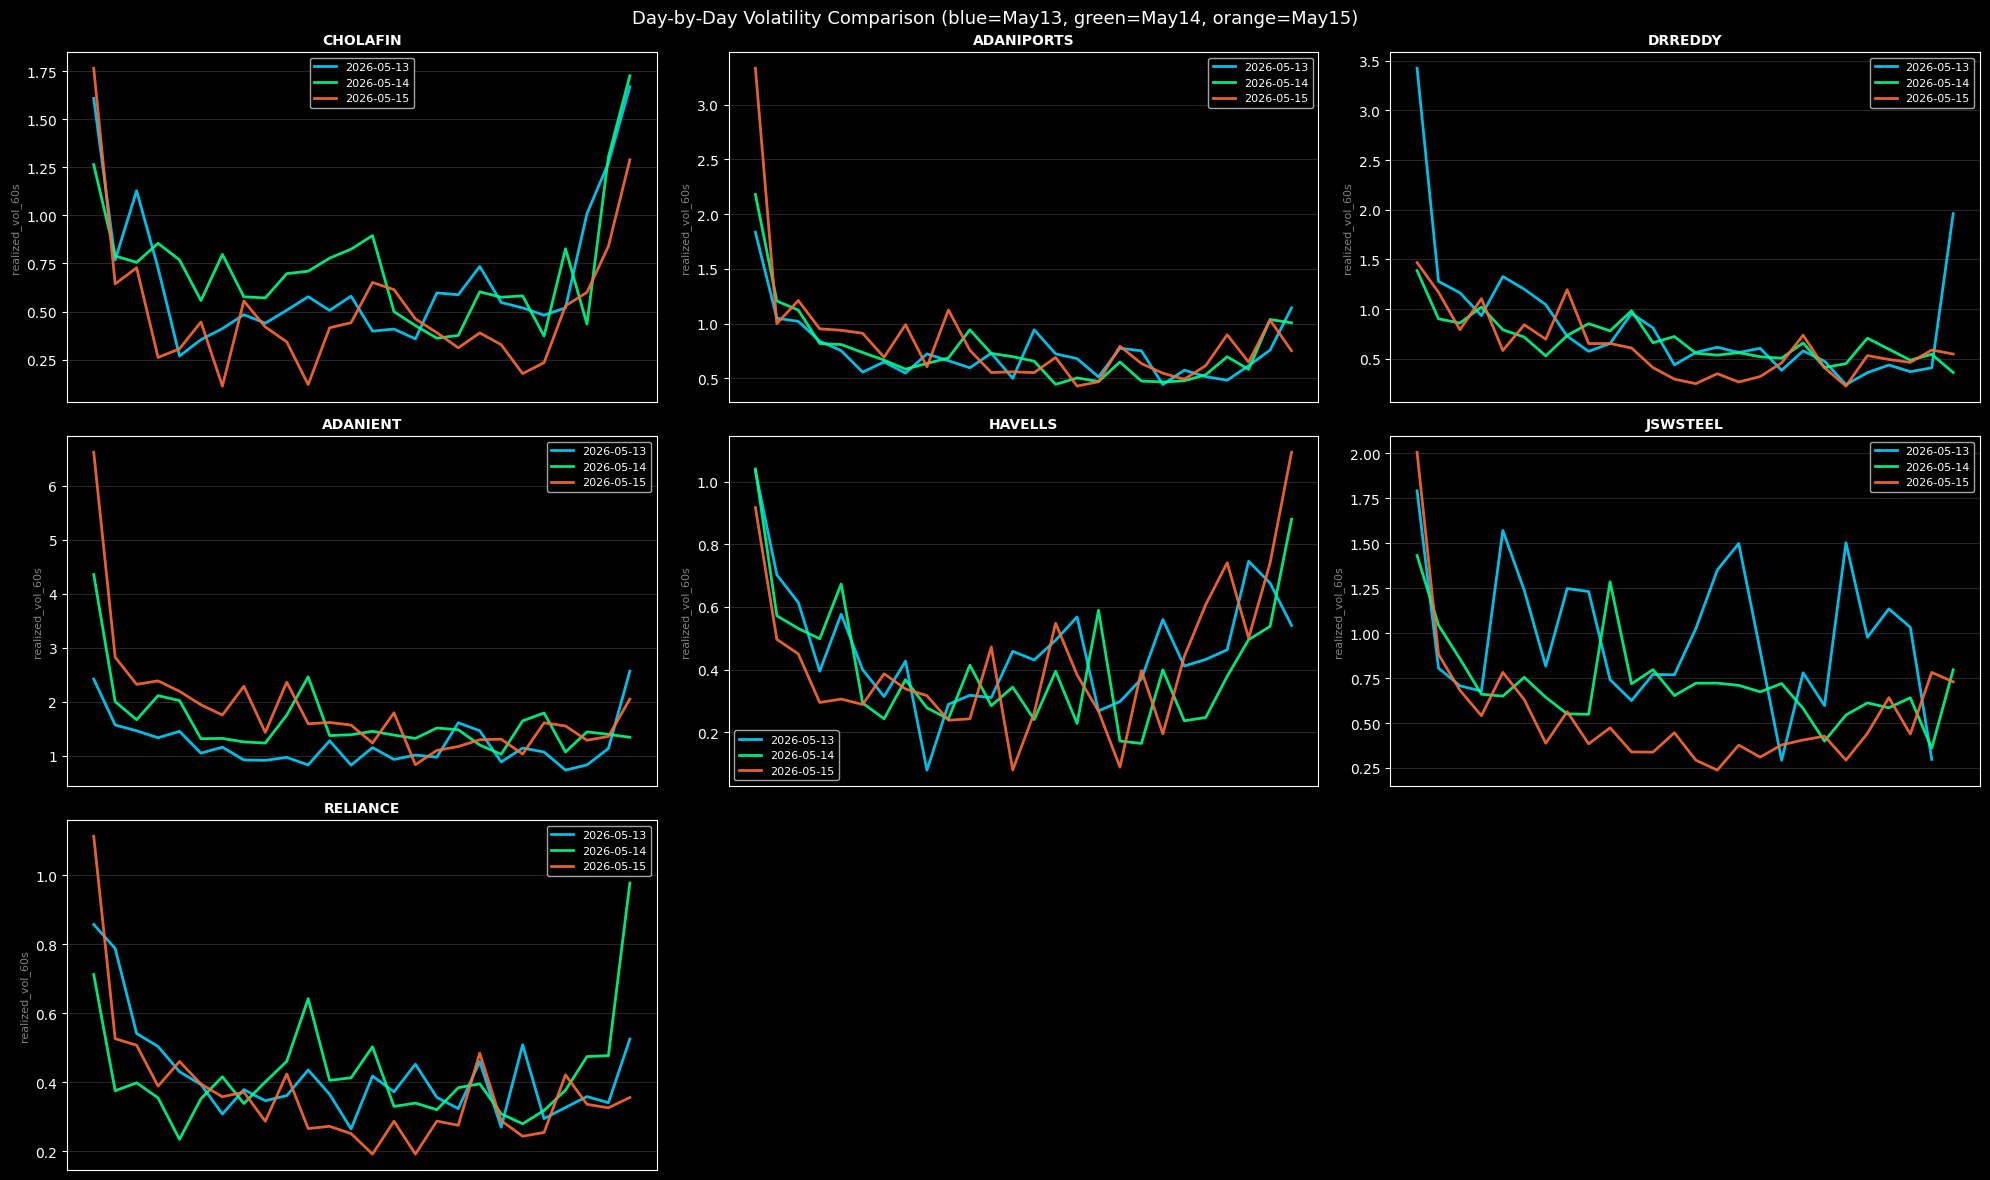

Saved: findings/vol_by_day.png


In [6]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

colors_day = {'2026-05-13': '#00d4ff', '2026-05-14': '#00ff88', '2026-05-15': '#ff6b35'}

for i, (sym, df) in enumerate(symbol_data.items()):
    ax  = axes[i]
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()

    bucket_sec    = 15 * 60
    mkt['bucket'] = (mkt['ist_tod_sec'] // bucket_sec) * bucket_sec
    mkt['hhmm']   = mkt['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )

    for date, color in colors_day.items():
        day_df = mkt[mkt['date'] == date]
        if day_df.empty:
            continue
        tod = day_df.groupby('hhmm')['realized_vol_60s'].mean().reset_index().sort_values('hhmm')
        ax.plot(range(len(tod)), tod['realized_vol_60s'], color=color, lw=2,
                label=date, alpha=0.9)

    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('realized_vol_60s', color='gray', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Day-by-Day Volatility Comparison (blue=May13, green=May14, orange=May15)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/vol_by_day.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/vol_by_day.png')

## 6. Which Vol Window Is Most Predictive?

We have 4 vol windows: 10s, 30s, 60s, 300s.  
The best one to use in mm_strategy.py is whichever best predicts **next-period** vol.  
We test: does vol_Xs at time t predict vol_60s at time t+1 (next bar)?

In [7]:
def test_vol_predictiveness(df: pd.DataFrame, target_col: str = 'realized_vol_60s',
                             horizon: int = 60) -> dict:
    """
    Test how well each vol window predicts vol horizon seconds ahead.
    Returns Pearson correlation for each vol window.
    """
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()
    mkt = mkt.sort_values('ts_sec').reset_index(drop=True)

    # Target: vol 60 bars (seconds) ahead
    mkt['target_vol'] = mkt[target_col].shift(-horizon)

    results = {}
    for col in VOL_COLS:
        if col not in mkt.columns:
            continue
        valid = mkt[[col, 'target_vol']].dropna()
        valid = valid[(valid[col] > 0) & (valid['target_vol'] > 0)]
        if len(valid) < 100:
            continue
        corr, pval = pearsonr(valid[col], valid['target_vol'])
        results[col] = {
            'corr':  round(float(corr), 4),
            'pval':  round(float(pval), 6),
            'n':     len(valid),
        }
    return results


vol_pred = {}
print(f"Predicting vol 60s ahead — Pearson correlation:")
print()
print(f"{'Symbol':25s} {'10s':>10} {'30s':>10} {'60s':>10} {'300s':>10} {'Best':>10}")
print('-' * 78)

for sym, df in symbol_data.items():
    res  = test_vol_predictiveness(df, horizon=60)
    vol_pred[sym] = res

    corrs = {col: res[col]['corr'] for col in VOL_COLS if col in res}
    best  = max(corrs, key=corrs.get) if corrs else 'N/A'

    print(f"{sym.replace('26MAYFUT',''):25s} "
          f"{corrs.get('realized_vol_10s', 0):>10.4f} "
          f"{corrs.get('realized_vol_30s', 0):>10.4f} "
          f"{corrs.get('realized_vol_60s', 0):>10.4f} "
          f"{corrs.get('realized_vol_300s', 0):>10.4f} "
          f"{best.replace('realized_vol_',''):>10}")

Predicting vol 60s ahead — Pearson correlation:

Symbol                           10s        30s        60s       300s       Best
------------------------------------------------------------------------------
CHOLAFIN                      0.2284     0.2221     0.2155     0.1918        10s
ADANIPORTS                    0.2730     0.3106     0.3752     0.3591        60s
DRREDDY                       0.4417     0.5646     0.5655     0.4458        60s
ADANIENT                      0.2170     0.3002     0.3423     0.3021        60s
HAVELLS                       0.2016     0.2094     0.2361     0.2480       300s
JSWSTEEL                      0.3226     0.3423     0.3760     0.3787       300s
RELIANCE                      0.2291     0.3077     0.3326     0.3538       300s


## 7. Vol Regime Classification

Classify each bar as LOW / MEDIUM / HIGH vol regime.  
For each regime, compute: what is the optimal spread multiplier?

This gives us a simple lookup table: `if vol > threshold → multiply spread by X`

In [8]:
vol_regimes = {}

print(f"{'Symbol':30s} {'Low (<P33)':>12} {'Med (P33-66)':>14} {'High (>P66)':>13} {'Ratio H/L':>11}")
print('-' * 84)

for sym, df in symbol_data.items():
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()
    v   = mkt['realized_vol_60s'].dropna()
    v   = v[v > 0]

    p33 = float(v.quantile(0.33))
    p66 = float(v.quantile(0.66))

    low_v  = float(v[v <= p33].mean())
    med_v  = float(v[(v > p33) & (v <= p66)].mean())
    high_v = float(v[v > p66].mean())
    ratio  = high_v / low_v if low_v > 0 else np.nan

    # Spread multiplier: since spread ∝ σ², multiplier = (high_v/low_v)²
    spread_mult = (high_v / low_v) ** 2 if low_v > 0 else np.nan

    vol_regimes[sym] = {
        'p33_vol':      round(p33, 6),
        'p66_vol':      round(p66, 6),
        'mean_low_vol': round(low_v, 6),
        'mean_med_vol': round(med_v, 6),
        'mean_high_vol':round(high_v, 6),
        'high_low_ratio':   round(ratio, 3),
        'spread_mult_high_vs_low': round(spread_mult, 2),
    }

    print(f"{sym:30s} {low_v:>12.6f} {med_v:>14.6f} {high_v:>13.6f} "
          f"{ratio:>11.2f}x  (spread mult: {spread_mult:.1f}x)")

print()
print('Spread mult = how much wider spread should be in HIGH vol vs LOW vol regime')

Symbol                           Low (<P33)   Med (P33-66)   High (>P66)   Ratio H/L
------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                   0.223894       0.529990      1.226014        5.48x  (spread mult: 30.0x)
ADANIPORTS26MAYFUT                 0.327309       0.648317      1.379630        4.22x  (spread mult: 17.8x)
DRREDDY26MAYFUT                    0.260615       0.564145      1.362113        5.23x  (spread mult: 27.3x)
ADANIENT26MAYFUT                   0.722014       1.300042      2.749638        3.81x  (spread mult: 14.5x)
HAVELLS26MAYFUT                    0.162026       0.405035      0.861953        5.32x  (spread mult: 28.3x)
JSWSTEEL26MAYFUT                   0.256567       0.527514      1.139951        4.44x  (spread mult: 19.7x)
RELIANCE26MAYFUT                   0.190811       0.339376      0.659940        3.46x  (spread mult: 12.0x)

Spread mult = how much wider spread should be in HIGH vol vs LOW vol regi

## 8. Optimal Spread by Vol Regime

Using the A-S formula with dynamic σ, compute what the spread should be  
in each vol regime. Compare to our current fixed params.

In [9]:
def as_spread(sigma: float, gamma: float = GAMMA, kappa: float = KAPPA,
              T: float = 1.0) -> float:
    """
    Avellaneda-Stoikov optimal half-spread.
    spread* = gamma * sigma^2 * T + (2/gamma) * ln(1 + gamma/kappa)
    """
    inventory_term  = gamma * sigma**2 * T
    selection_term  = (2 / gamma) * np.log(1 + gamma / kappa)
    return inventory_term + selection_term


print(f"{'Symbol':30s} {'Low σ spread':>14} {'Med σ spread':>14} {'High σ spread':>15} {'Current min':>13}")
print('-' * 90)

spread_by_regime = {}
for sym in symbol_data:
    reg = vol_regimes.get(sym, {})
    if not reg:
        continue

    s_low  = as_spread(reg['mean_low_vol'])
    s_med  = as_spread(reg['mean_med_vol'])
    s_high = as_spread(reg['mean_high_vol'])

    spread_by_regime[sym] = {
        'spread_low_vol':  round(s_low, 4),
        'spread_med_vol':  round(s_med, 4),
        'spread_high_vol': round(s_high, 4),
        'current_min_spread': 0.10,
    }

    flag = ' ← too tight!' if s_high > 0.10 and s_high > s_low * 1.5 else ''
    print(f"{sym:30s} {s_low:>14.4f} {s_med:>14.4f} {s_high:>15.4f} {'0.10':>13}{flag}")

print()
print('If high-vol spread >> 0.10, our min_spread is too tight on volatile days → losses')

Symbol                           Low σ spread   Med σ spread   High σ spread   Current min
------------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                       1.3329         1.3332          1.3344          0.10
ADANIPORTS26MAYFUT                     1.3330         1.3333          1.3348          0.10
DRREDDY26MAYFUT                        1.3330         1.3332          1.3347          0.10
ADANIENT26MAYFUT                       1.3334         1.3346          1.3404          0.10
HAVELLS26MAYFUT                        1.3329         1.3331          1.3336          0.10
JSWSTEEL26MAYFUT                       1.3330         1.3332          1.3342          0.10
RELIANCE26MAYFUT                       1.3329         1.3330          1.3333          0.10

If high-vol spread >> 0.10, our min_spread is too tight on volatile days → losses


## 9. Vol Autocorrelation — How Long Does a Vol Regime Last?

If vol is persistent (autocorrelated), we can use current vol to predict near-future vol.  
If it's not persistent, we need a faster-updating estimate.

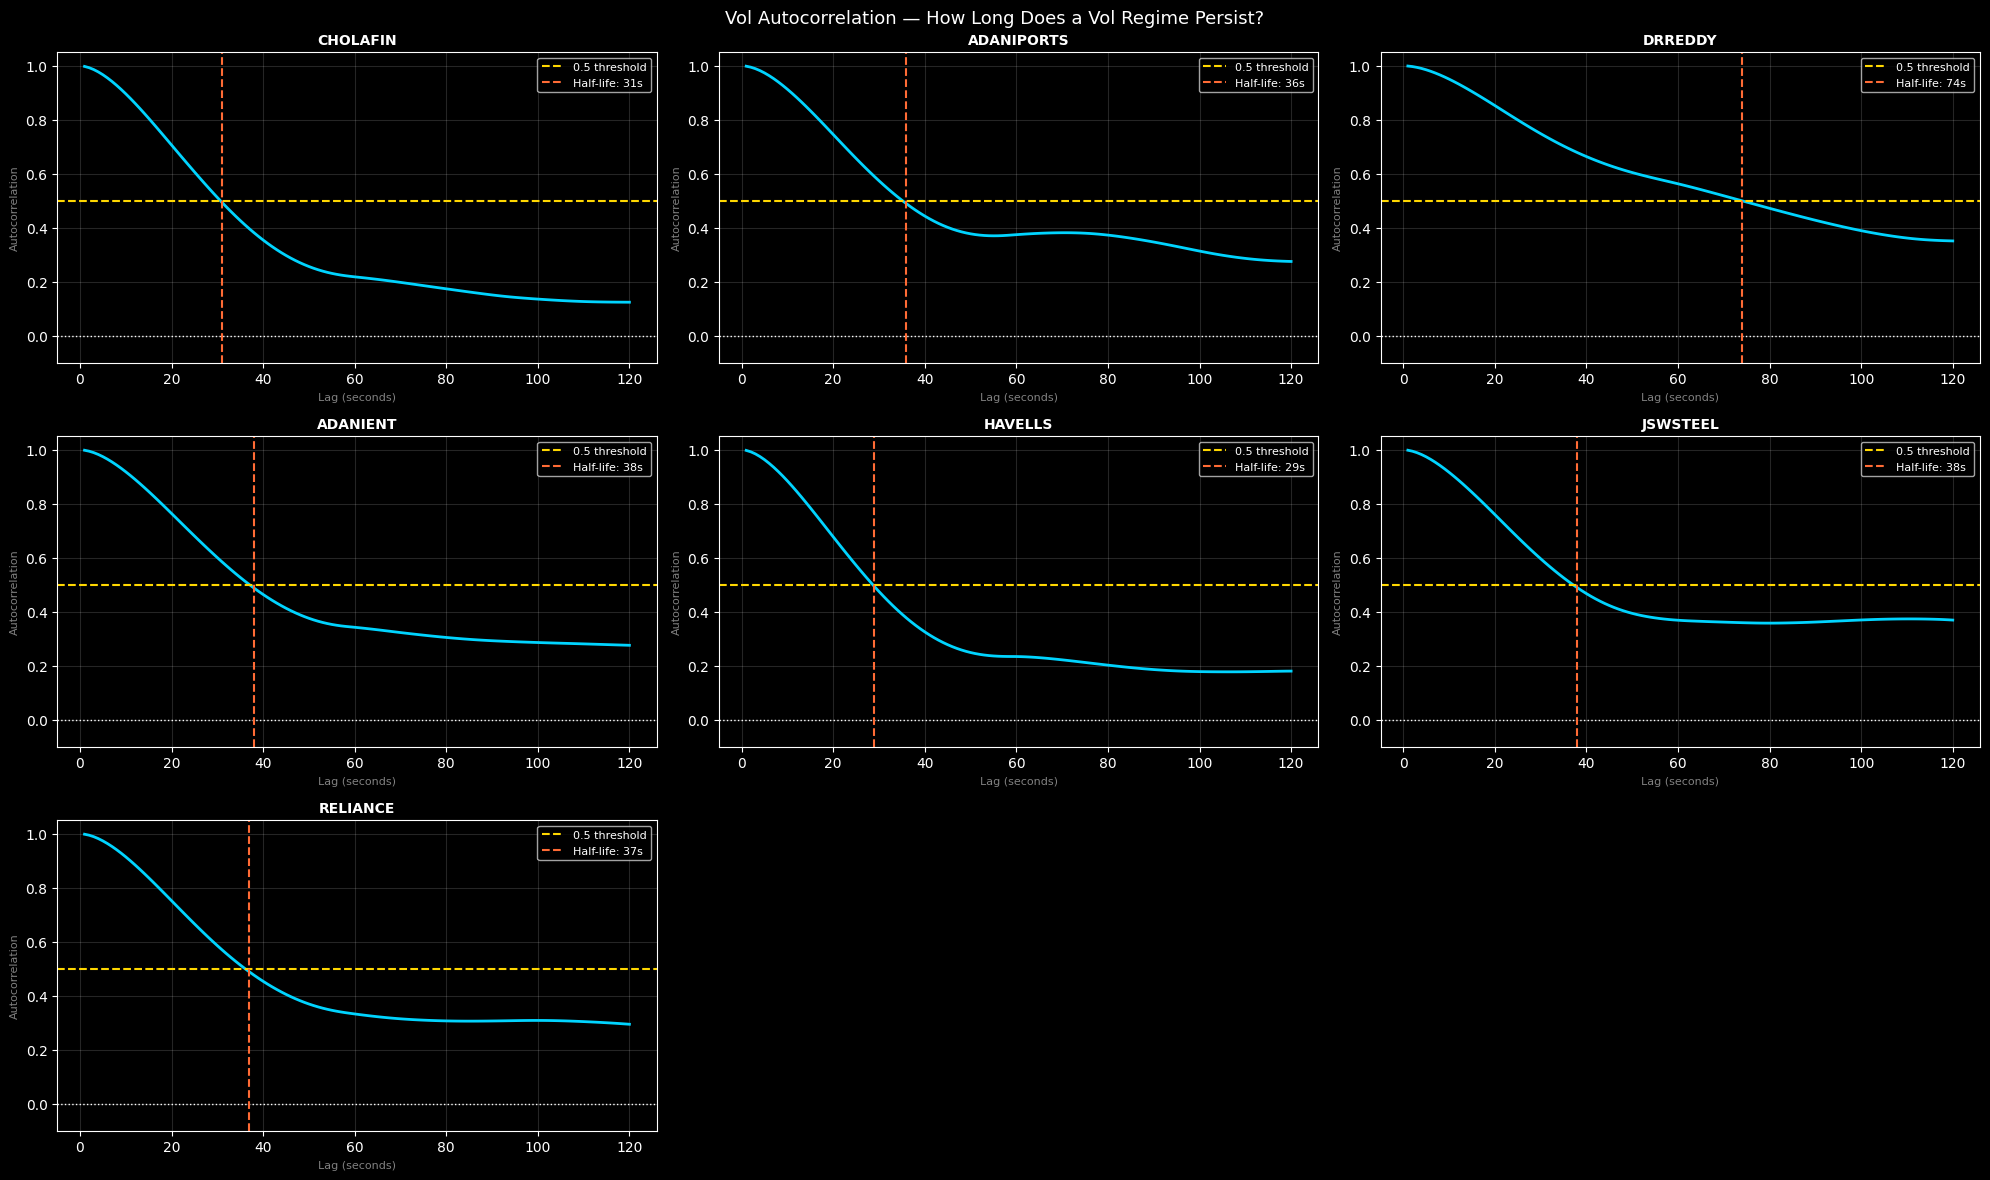


Symbol                          Half-life (s)   ACF lag=1   ACF lag=60
------------------------------------------------------------------------
CHOLAFIN26MAYFUT                           31      0.9978       0.2182
ADANIPORTS26MAYFUT                         36      0.9986       0.3744
DRREDDY26MAYFUT                            74      0.9992       0.5629
ADANIENT26MAYFUT                           38      0.9985       0.3425
HAVELLS26MAYFUT                            29      0.9979       0.2341
JSWSTEEL26MAYFUT                           38      0.9985       0.3687
RELIANCE26MAYFUT                           37      0.9985       0.3327

Half-life = how many seconds before vol regime changes significantly
Use this to choose update frequency for dynamic σ in mm_strategy.py


In [10]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

vol_autocorr = {}
max_lag = 120  # seconds

for i, (sym, df) in enumerate(symbol_data.items()):
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()
    v   = mkt['realized_vol_60s'].dropna().values
    v   = v[v > 0]

    # Autocorrelation at lags 1..max_lag seconds
    acf = []
    for lag in range(1, max_lag + 1):
        if lag >= len(v):
            break
        corr = np.corrcoef(v[:-lag], v[lag:])[0, 1]
        acf.append(corr)

    lags = list(range(1, len(acf) + 1))

    # Find half-life: lag at which autocorr drops below 0.5
    half_life = next((l for l, c in zip(lags, acf) if c < 0.5), max_lag)
    vol_autocorr[sym] = {
        'half_life_sec': half_life,
        'acf_lag1':      round(acf[0], 4) if acf else None,
        'acf_lag60':     round(acf[59], 4) if len(acf) > 59 else None,
    }

    ax = axes[i]
    ax.plot(lags, acf, color='#00d4ff', lw=2)
    ax.axhline(0.5, color='#ffd700', lw=1.5, ls='--', label='0.5 threshold')
    ax.axhline(0,   color='white',   lw=1,   ls=':')
    ax.axvline(half_life, color='#ff6b35', lw=1.5, ls='--',
               label=f'Half-life: {half_life}s')
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lag (seconds)', color='gray', fontsize=8)
    ax.set_ylabel('Autocorrelation', color='gray', fontsize=8)
    ax.set_ylim(-0.1, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Vol Autocorrelation — How Long Does a Vol Regime Persist?',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/vol_autocorr.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print(f"\n{'Symbol':30s} {'Half-life (s)':>14} {'ACF lag=1':>11} {'ACF lag=60':>12}")
print('-' * 72)
for sym, s in vol_autocorr.items():
    print(f"{sym:30s} {s['half_life_sec']:>14} {str(s['acf_lag1']):>11} {str(s['acf_lag60']):>12}")

print()
print('Half-life = how many seconds before vol regime changes significantly')
print('Use this to choose update frequency for dynamic σ in mm_strategy.py')

## 10. Practical Dynamic σ Formula

Based on the analysis, derive the simplest formula that works in real-time.  
Options from simple to complex:

1. **EWM** — exponentially weighted moving average of returns² (simplest)
2. **Use realized_vol_Xs directly** — already computed in your pipeline
3. **Regime lookup** — classify into LOW/MED/HIGH and use pre-computed σ

We test all three and compare predictive accuracy.

In [11]:
def test_sigma_estimators(df: pd.DataFrame, horizon: int = 60) -> dict:
    """
    Compare 3 sigma estimators against realized vol horizon seconds ahead.
    Returns MAE for each estimator.
    """
    mkt = df[(df['ist_hhmm'] >= '09:15') & (df['ist_hhmm'] <= '15:30')].copy()
    mkt = mkt.sort_values('ts_sec').reset_index(drop=True)

    # Target: actual vol horizon seconds ahead
    mkt['target'] = mkt['realized_vol_60s'].shift(-horizon)

    # Estimator 1: realized_vol_60s (current bar, use as-is)
    mkt['est_60s'] = mkt['realized_vol_60s']

    # Estimator 2: realized_vol_300s (slower, more stable)
    mkt['est_300s'] = mkt['realized_vol_300s']

    # Estimator 3: EWM of returns (span=60 bars)
    mkt['ret']     = mkt['close'].pct_change()
    mkt['est_ewm'] = mkt['ret'].ewm(span=60).std()

    # Estimator 4: rolling mean of realized_vol_60s over last 5 mins
    mkt['est_roll'] = mkt['realized_vol_60s'].rolling(300, min_periods=30).mean()

    results = {}
    for est in ['est_60s', 'est_300s', 'est_ewm', 'est_roll']:
        valid = mkt[['target', est]].dropna()
        valid = valid[(valid['target'] > 0) & (valid[est] > 0)]
        if len(valid) < 50:
            continue
        mae  = float(np.abs(valid['target'] - valid[est]).mean())
        corr = float(valid['target'].corr(valid[est]))
        results[est] = {'mae': round(mae, 8), 'corr': round(corr, 4), 'n': len(valid)}

    return results


sigma_tests = {}
print('MAE comparison (lower = better predictor of next-60s vol):')
print()
print(f"{'Symbol':25s} {'vol_60s':>10} {'vol_300s':>10} {'EWM':>10} {'Roll5min':>10} {'Best':>10}")
print('-' * 80)

for sym, df in symbol_data.items():
    res  = test_sigma_estimators(df, horizon=60)
    sigma_tests[sym] = res

    maes = {k: v['mae'] for k, v in res.items()}
    best = min(maes, key=maes.get) if maes else 'N/A'
    best_label = best.replace('est_', '')

    print(f"{sym.replace('26MAYFUT',''):25s} "
          f"{maes.get('est_60s', 0):>10.8f} "
          f"{maes.get('est_300s', 0):>10.8f} "
          f"{maes.get('est_ewm', 0):>10.8f} "
          f"{maes.get('est_roll', 0):>10.8f} "
          f"{best_label:>10}")

MAE comparison (lower = better predictor of next-60s vol):

Symbol                       vol_60s   vol_300s        EWM   Roll5min       Best
--------------------------------------------------------------------------------
CHOLAFIN                  0.48483754 0.95934864 0.65914743 0.40034089       roll
ADANIPORTS                0.47004667 1.09189889 0.78431538 0.40460351       roll
DRREDDY                   0.41747208 1.04822581 0.71864512 0.37729664       roll
ADANIENT                  0.85988424 2.19291011 1.59579758 0.75036945       roll
HAVELLS                   0.32622531 0.57787323 0.47718962 0.26477850       roll
JSWSTEEL                  0.35932578 0.79124411 0.64035061 0.29291404       roll
RELIANCE                  0.20832015 0.45676202 0.39643221 0.17512787       roll


## 11. Save Findings

In [12]:
# Load existing findings
queue_path = os.path.join(FINDINGS_DIR, 'queue_analysis.json')
existing   = json.loads(open(queue_path).read()) if os.path.exists(queue_path) else {}

findings = {}
for sym in symbol_data:
    # Best vol estimator
    st   = sigma_tests.get(sym, {})
    maes = {k: v['mae'] for k, v in st.items()}
    best_est = min(maes, key=maes.get).replace('est_', '') if maes else 'vol_60s'

    # Best vol window for prediction
    vp   = vol_pred.get(sym, {})
    corrs = {col: vp[col]['corr'] for col in VOL_COLS if col in vp}
    best_vol_col = max(corrs, key=corrs.get) if corrs else 'realized_vol_60s'

    findings[sym] = {
        **{k: v for k, v in existing.get(sym, {}).items()},
        'vol_summary':       vol_summary.get(sym, {}),
        'vol_by_day':        day_vol.get(sym, {}),
        'vol_regimes':       vol_regimes.get(sym, {}),
        'spread_by_regime':  spread_by_regime.get(sym, {}),
        'vol_autocorr':      vol_autocorr.get(sym, {}),
        'best_vol_estimator':    best_est,
        'best_vol_col_predictive': best_vol_col,
        'sigma_test_maes':   {k: v['mae'] for k, v in st.items()},
        'updated_at':        datetime.now().isoformat(),
    }

output_path = os.path.join(FINDINGS_DIR, 'vol_analysis.json')
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2, default=str)

print(f'Saved → {output_path}\n')
print(f"{'Symbol':30s} {'Half-life':>11} {'Best est':>12} {'High/Low ratio':>16} {'Spread mult':>13}")
print('-' * 88)
for sym, f_ in findings.items():
    hl   = f_.get('vol_autocorr', {}).get('half_life_sec', 'N/A')
    be   = f_.get('best_vol_estimator', 'N/A')
    hl_r = f_.get('vol_regimes', {}).get('high_low_ratio', 'N/A')
    sm   = f_.get('vol_regimes', {}).get('spread_mult_high_vs_low', 'N/A')
    print(f"{sym:30s} {str(hl):>11} {str(be):>12} {str(hl_r):>16} {str(sm):>13}")

Saved → ../findings\vol_analysis.json

Symbol                           Half-life     Best est   High/Low ratio   Spread mult
----------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                        31         roll            5.476         29.99
ADANIPORTS26MAYFUT                      36         roll            4.215         17.77
DRREDDY26MAYFUT                         74         roll            5.227         27.32
ADANIENT26MAYFUT                        38         roll            3.808          14.5
HAVELLS26MAYFUT                         29         roll             5.32          28.3
JSWSTEEL26MAYFUT                        38         roll            4.443         19.74
RELIANCE26MAYFUT                        37         roll            3.459         11.96


## 12. Integration Code for mm_strategy.py

The simplest effective implementation — drop-in replacement for fixed σ.

In [ ]:
print('''
# ── Dynamic σ in MMStrategy ───────────────────────────────────────────────────

import json
from pathlib import Path

_VOL_PATH = Path(__file__).parents[2] / 'research' / 'findings' / 'vol_analysis.json'
_VOL_DATA = json.loads(_VOL_PATH.read_text()) if _VOL_PATH.exists() else {}

# In MMStrategy.__init__:
sym_vol = _VOL_DATA.get(symbol, {}).get('vol_regimes', {})
self.sigma_low  = sym_vol.get('mean_low_vol',  0.0001)  # use in quiet periods
self.sigma_high = sym_vol.get('mean_high_vol', 0.0003)  # use in volatile periods
self.vol_p66    = sym_vol.get('p66_vol',       0.0002)  # threshold: above = high regime

# In MMStrategy.on_bar(bar):
# Option A — direct (use the pre-computed column, fastest)
self.sigma = bar.get('realized_vol_60s') or self.sigma_low
self.sigma = max(self.sigma, self.sigma_low)  # floor at low-regime vol

# Option B — regime-based (more stable)
current_vol = bar.get('realized_vol_60s', self.sigma_low)
self.sigma  = self.sigma_high if current_vol > self.vol_p66 else self.sigma_low

# Then use self.sigma in A-S formula as usual:
# spread = gamma * sigma**2 * T + ...
''')

## 13. Conclusions

*(Fill in after running)*

### Key Questions to Answer
1. Was May 15 vol significantly higher than May 13/14? (explains bad day)
2. What is the high/low spread multiplier per symbol? (how much to widen on bad days)
3. How long does a vol regime last? (half-life → how often to update σ)
4. Which estimator is most predictive? (what to use in mm_strategy.py)
5. Is current min_spread=0.10 ever too tight for high-vol regime?

### Action Items
- [ ] Integrate dynamic σ into `mm_strategy.py` using Option A or B above
- [ ] Re-run backtest on May 15 with dynamic σ — expect significant improvement
- [ ] Set symbol-specific vol floors from `vol_regimes.mean_low_vol`
- [ ] Set symbol-specific min_spread from `spread_by_regime.spread_high_vol` for high-vol days
- [ ] Next: `04_regime_detection.ipynb` — trending vs mean-reverting day classification